In [263]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [264]:
df = pd.read_csv(r'movie.csv')

## Exploratary Data Analysis (EDA)

In [265]:
df.head()

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,Director,Star1,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142 min,Drama,9.3,80.0,Frank Darabont,Tim Robbins,2343110,28341469.0
1,The Godfather,1972,A,175 min,"Crime, Drama",9.2,100.0,Francis Ford Coppola,Marlon Brando,1620367,134966411.0
2,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,84.0,Christopher Nolan,Christian Bale,2303232,534858444.0
3,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,90.0,Francis Ford Coppola,Al Pacino,1129952,57300000.0
4,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,96.0,Sidney Lumet,Henry Fonda,689845,4360000.0


In [266]:
print(f'Rows = {df.shape[0]}')
print(f'Columns = {df.shape[1]}')

Rows = 1000
Columns = 11


In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   1000 non-null   object 
 1   Released_Year  1000 non-null   object 
 2   Certificate    899 non-null    object 
 3   Runtime        1000 non-null   object 
 4   Genre          1000 non-null   object 
 5   IMDB_Rating    1000 non-null   float64
 6   Meta_score     843 non-null    float64
 7   Director       1000 non-null   object 
 8   Star1          1000 non-null   object 
 9   No_of_Votes    1000 non-null   int64  
 10  Gross          831 non-null    float64
dtypes: float64(3), int64(1), object(7)
memory usage: 86.1+ KB


In [268]:
df.isnull().sum()

Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Meta_score       157
Director           0
Star1              0
No_of_Votes        0
Gross            169
dtype: int64

In [269]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,1000.000000,843.000000,1.000000e+03,8.310000e+02
mean,7.949300,77.971530,2.736929e+05,6.803475e+07
std,0.275491,12.376099,3.273727e+05,1.097500e+08
min,7.600000,28.000000,2.508800e+04,1.305000e+03
25%,7.700000,70.000000,5.552625e+04,3.253559e+06
50%,7.900000,79.000000,1.385485e+05,2.353089e+07
75%,8.100000,87.000000,3.741612e+05,8.075089e+07
max,9.300000,100.000000,2.343110e+06,9.366622e+08


In [270]:
df.dtypes

Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Meta_score       float64
Director          object
Star1             object
No_of_Votes        int64
Gross            float64
dtype: object

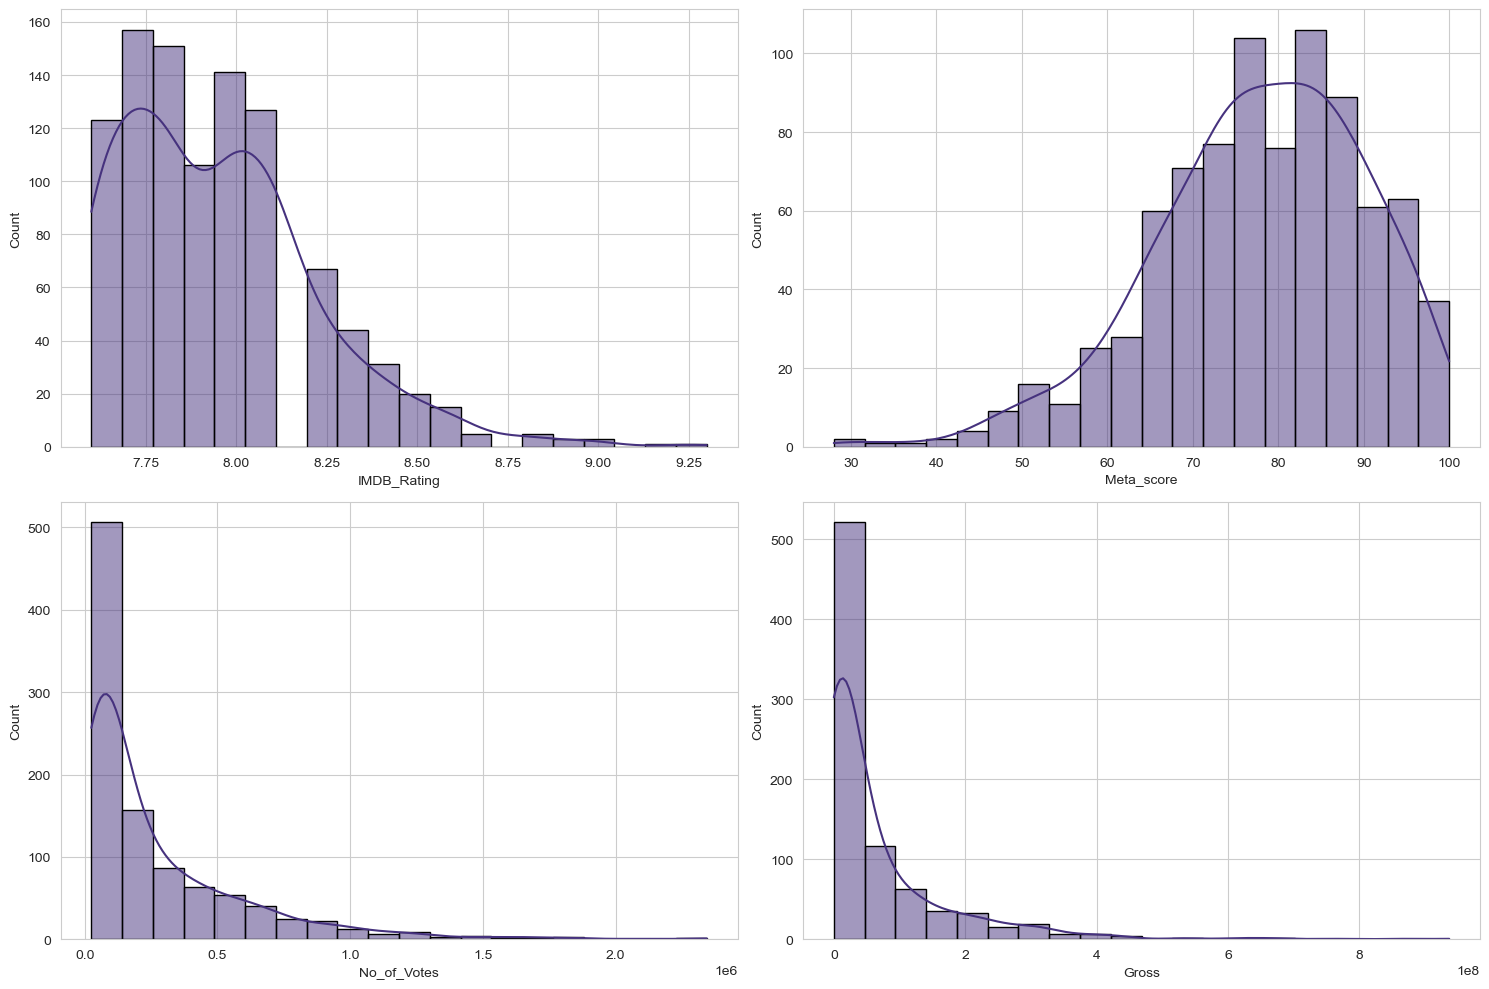

In [271]:
fig, axes = plt.subplots(2, 2, figsize = (15, 10))
axes = axes.flatten()

columns = df.select_dtypes([int, float]).columns

sns.set_style("whitegrid")

for i, col in enumerate(columns):
    sns.set_palette('viridis')
    sns.histplot(df[col], kde = True, ax = axes[i], edgecolor = 'Black', bins = 20)

plt.tight_layout()
plt.show()

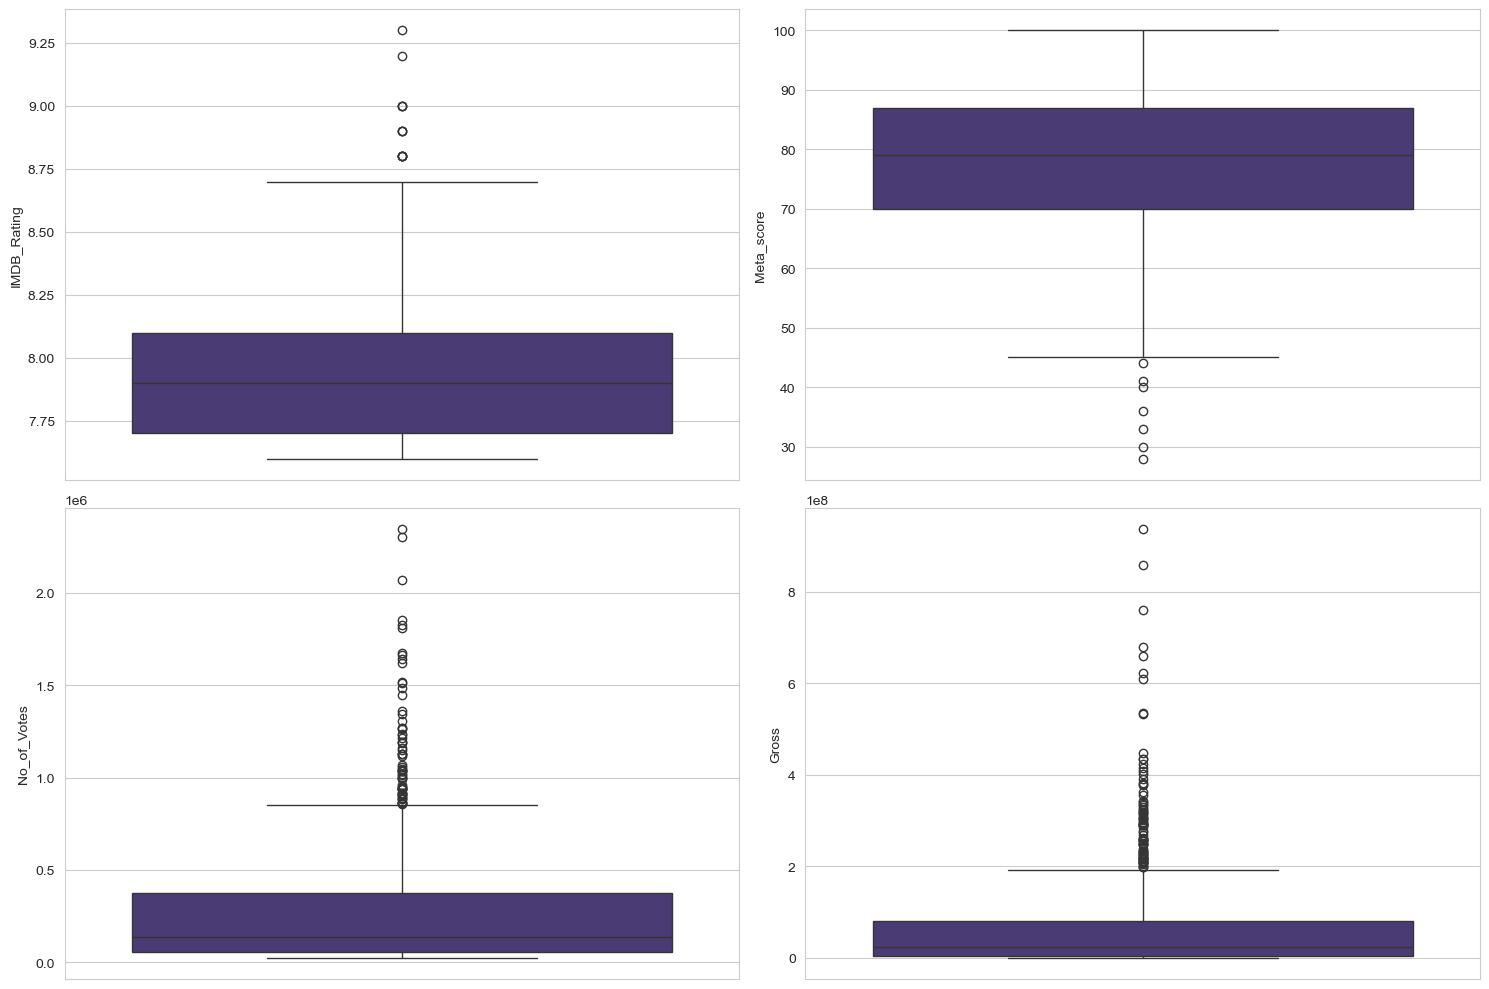

In [272]:
fig, axes = plt.subplots(2, 2, figsize = (15, 10))
axes = axes.flatten()

columns = df.select_dtypes([int, float]).columns

sns.set_style("whitegrid")

for i, col in enumerate(columns):
    sns.set_palette('viridis')
    sns.boxplot(df[col], ax = axes[i])

plt.tight_layout()
plt.show()

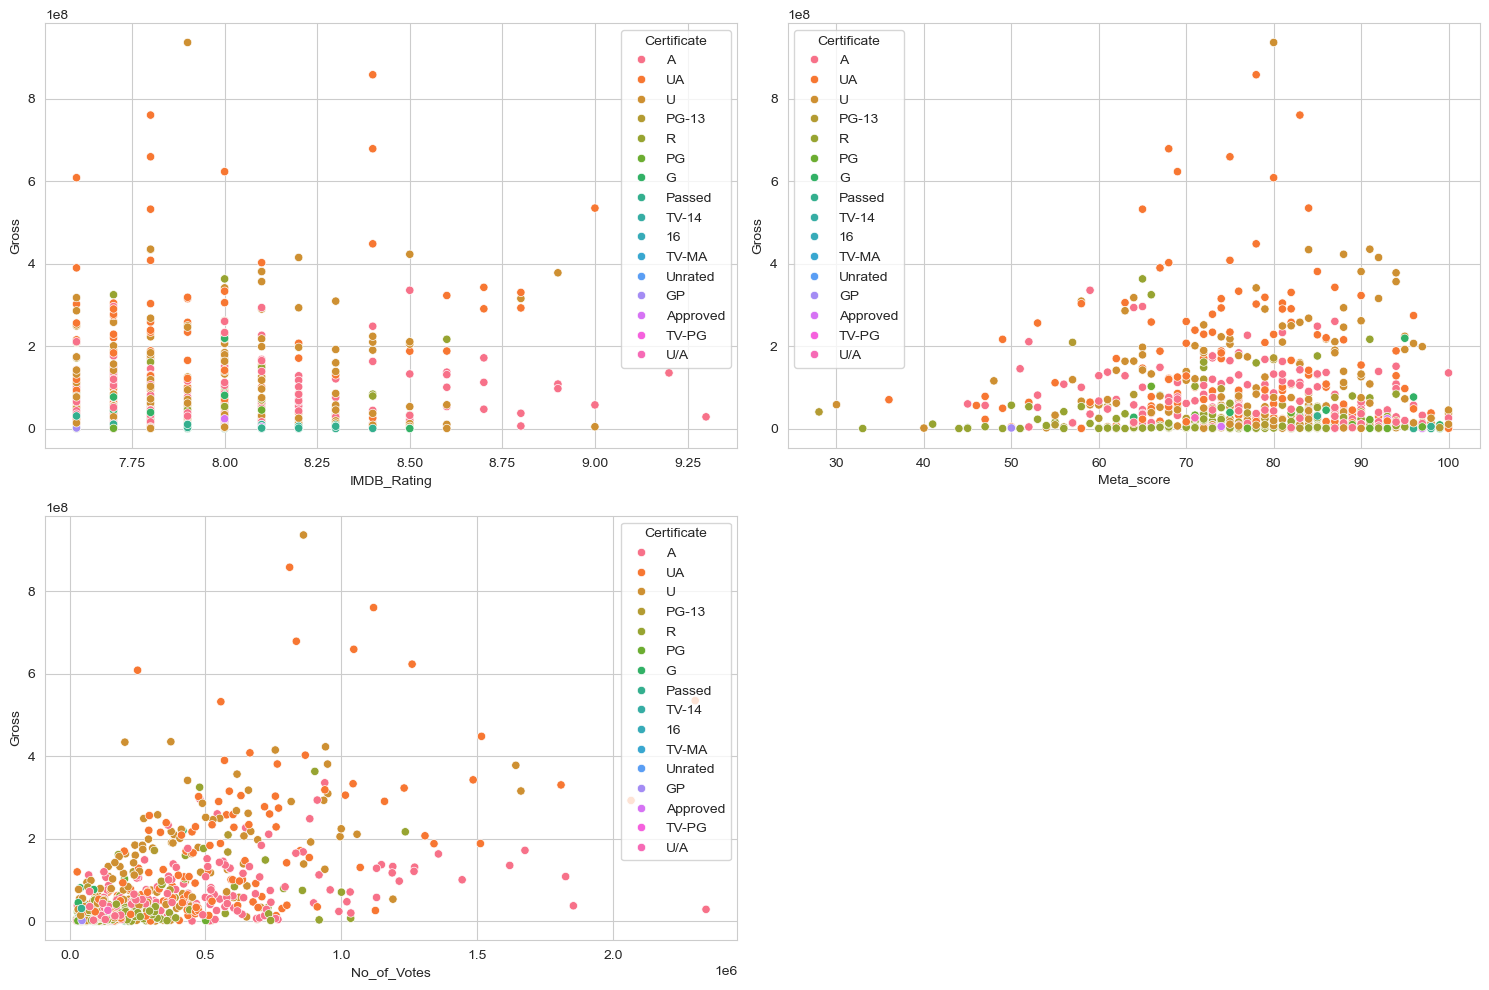

In [273]:
fig, axes = plt.subplots(2, 2, figsize = (15, 10))
axes = axes.flatten()

columns = df.select_dtypes([int, float]).columns

sns.set_style("whitegrid")

for i, col in enumerate(columns):
    if i <= 2:
        sns.set_palette('viridis')
        sns.scatterplot(x = df[col], y = df['Gross'], hue = df['Certificate'], ax = axes[i])
        
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig.delaxes(axes[3])
plt.tight_layout()
plt.show()

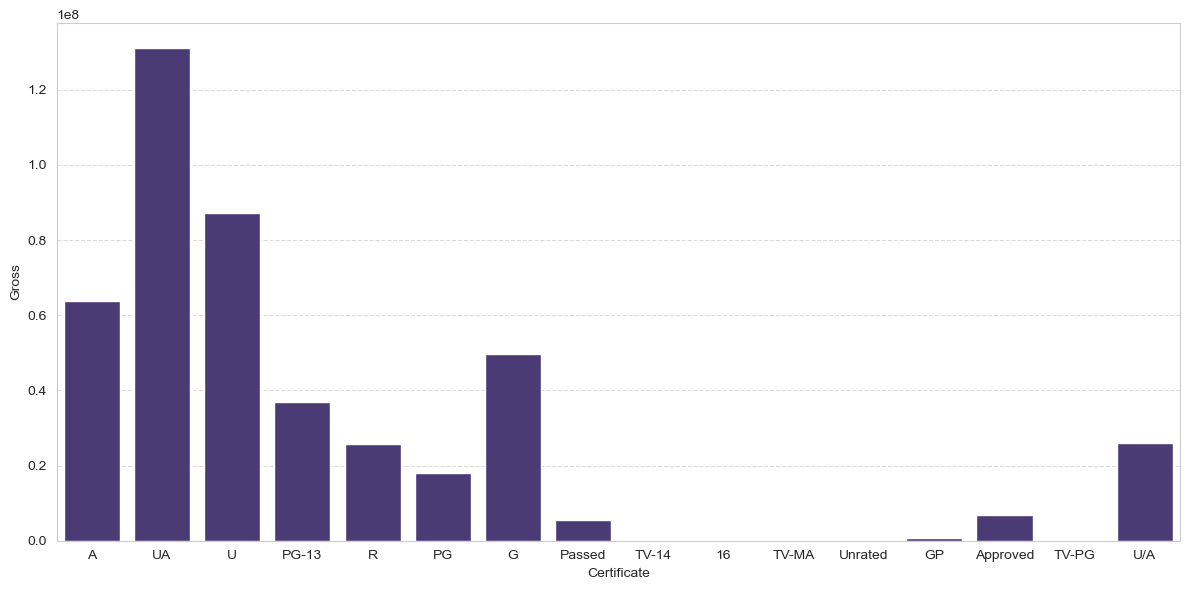

In [274]:
plt.figure(figsize = (12, 6))

sns.set_style("whitegrid")
sns.set_palette('viridis')

sns.barplot(x = df['Certificate'], y = df['Gross'], errorbar = None)

plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

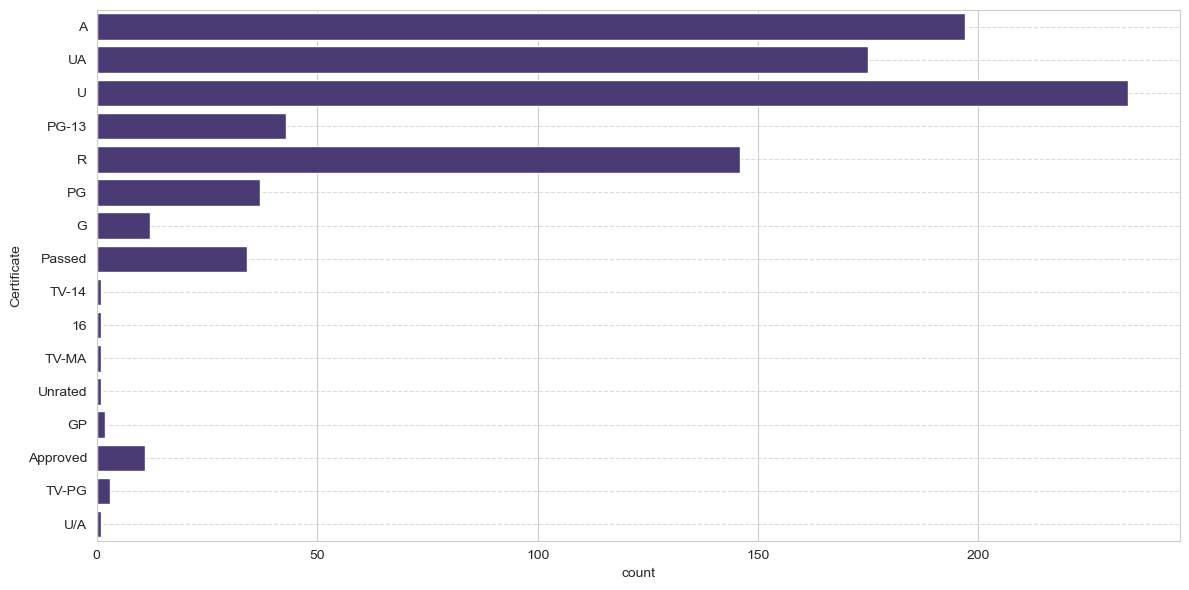

In [275]:
plt.figure(figsize = (12, 6))

sns.set_style("whitegrid")
sns.set_palette('viridis')

sns.countplot(df['Certificate'])

plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

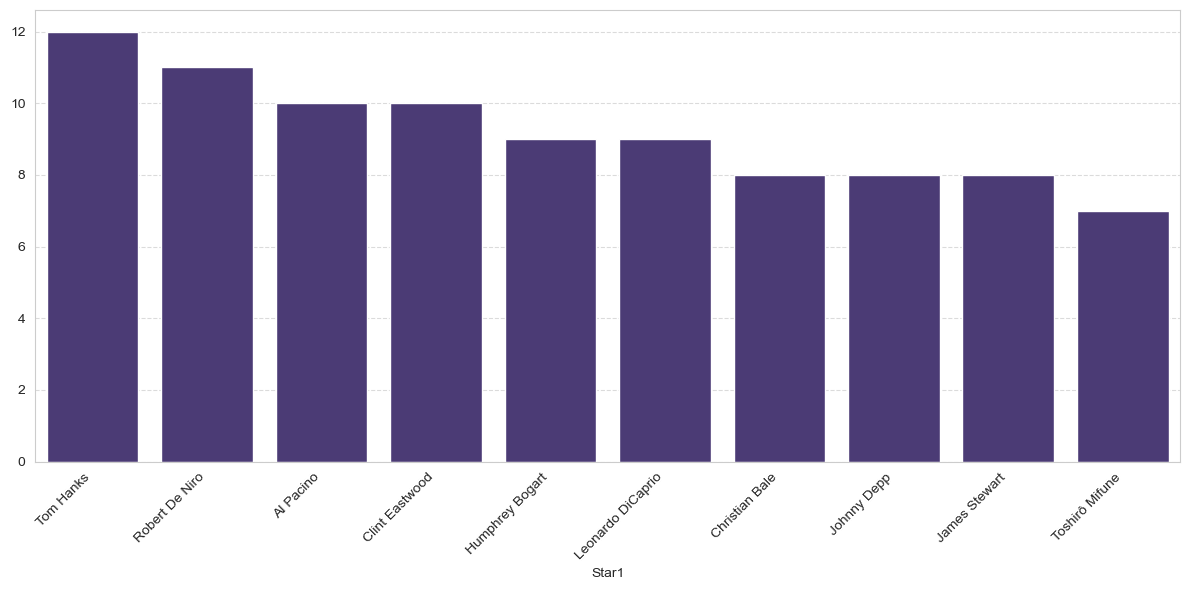

In [276]:
plt.figure(figsize = (12, 6))

sns.set_style("whitegrid")
sns.set_palette('viridis')

sns.barplot(y = df['Star1'].value_counts().head(10).values, x = df['Star1'].value_counts().head(10).index, errorbar = None)

plt.xticks(rotation = 45, ha = 'right')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

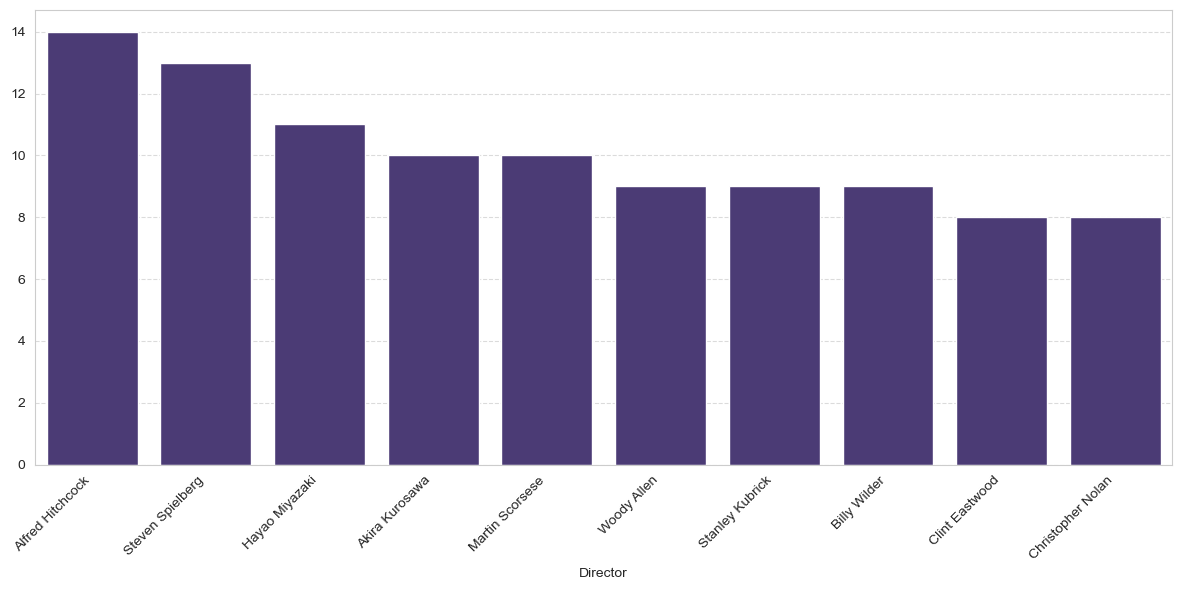

In [277]:
plt.figure(figsize = (12, 6))

sns.set_style("whitegrid")
sns.set_palette('viridis')

sns.barplot(y = df['Director'].value_counts().head(10).values, x = df['Director'].value_counts().head(10).index, errorbar = None)

plt.xticks(rotation = 45, ha='right')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

In [278]:
sorted_df_director = df.sort_values(by = ['Gross'], ascending = False).head(10)

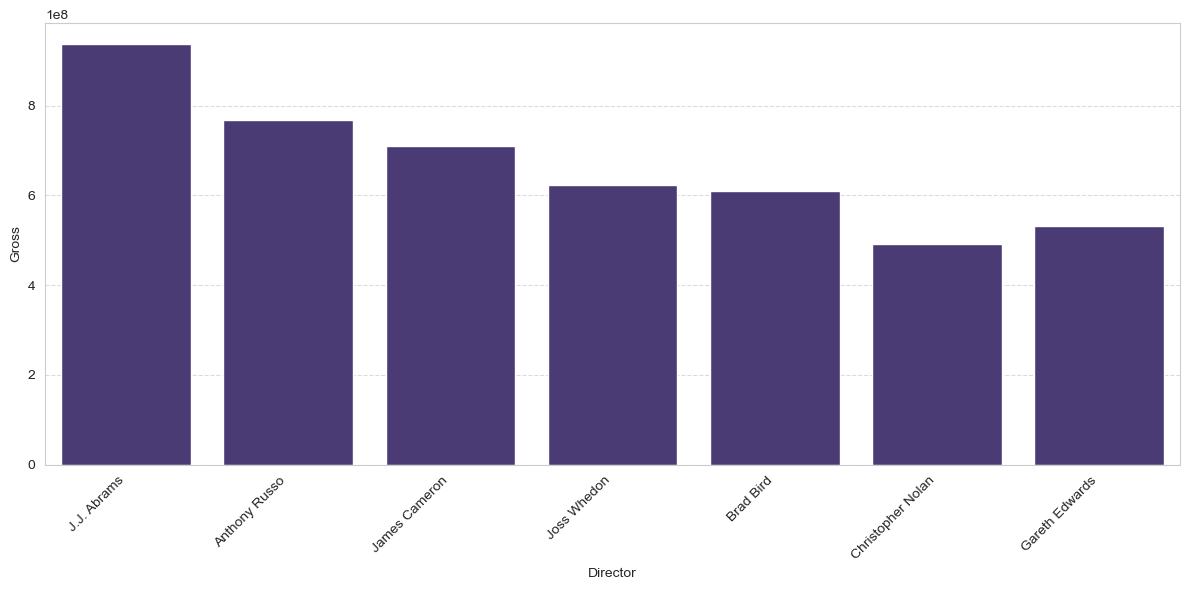

In [279]:
plt.figure(figsize = (12, 6))

sns.set_style("whitegrid")
sns.set_palette('viridis')

sns.barplot(x = sorted_df_director.Director, y = sorted_df_director.Gross, errorbar = None)

plt.xticks(rotation = 45, ha='right')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

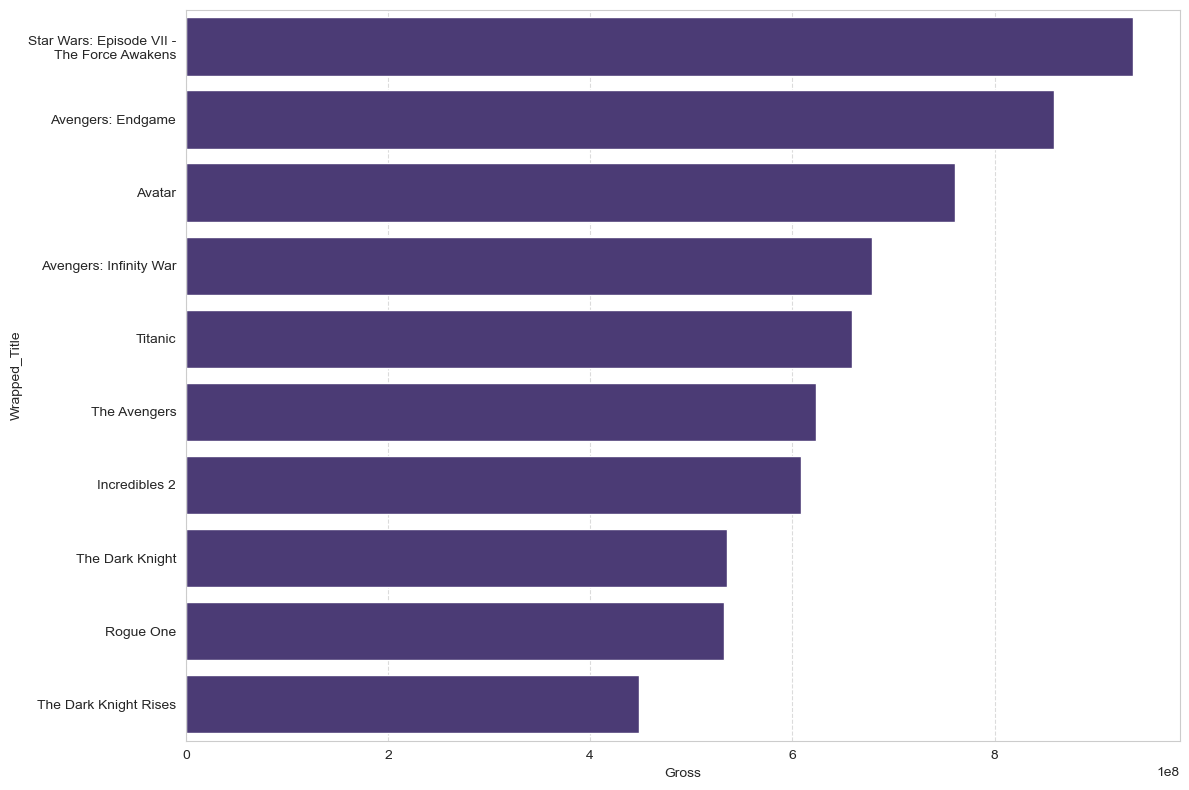

In [280]:
import textwrap

def wrap_text(label, width = 25):
    return '\n'.join(textwrap.wrap(label, width))

sorted_df_director['Wrapped_Title'] = sorted_df_director['Series_Title'].apply(lambda x: wrap_text(x, width=25))

plt.figure(figsize=(12, 8))  

sns.set_style("whitegrid")
sns.set_palette('viridis')

sns.barplot(y = sorted_df_director.Wrapped_Title, x = sorted_df_director.Gross, errorbar = None)
plt.subplots_adjust(left = 0.25)  

plt.grid(axis = 'x', linestyle = '--', alpha = 0.7) 

plt.tight_layout()
plt.show()

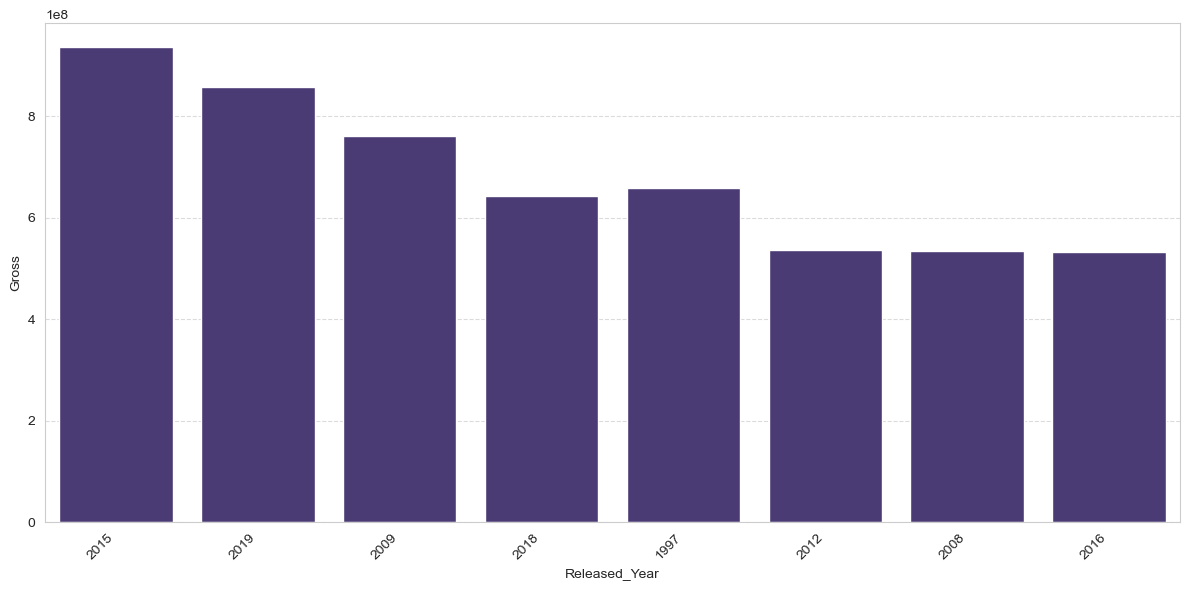

In [281]:
plt.figure(figsize = (12, 6))

sns.set_style("whitegrid")
sns.set_palette('viridis')

sns.barplot(x = sorted_df_director.Released_Year, y = sorted_df_director.Gross, errorbar = None)

plt.xticks(rotation = 45, ha = 'right')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

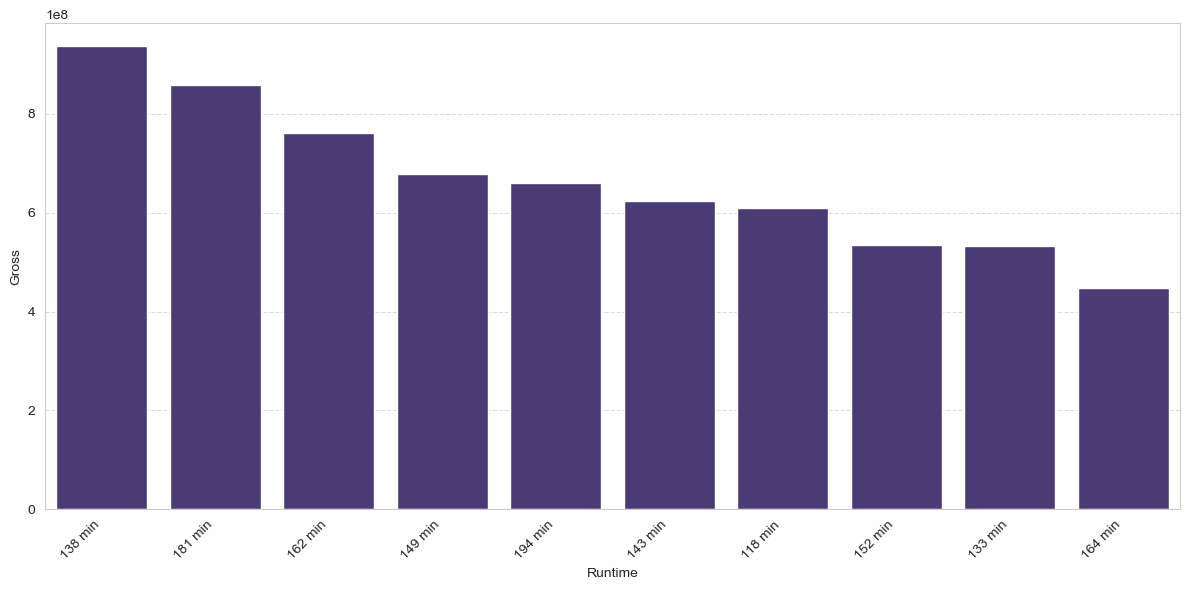

In [282]:
plt.figure(figsize = (12, 6))

sns.set_style("whitegrid")
sns.set_palette('viridis')

sns.barplot(x = sorted_df_director.Runtime, y = sorted_df_director.Gross, errorbar = None)

plt.xticks(rotation = 45, ha = 'right')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

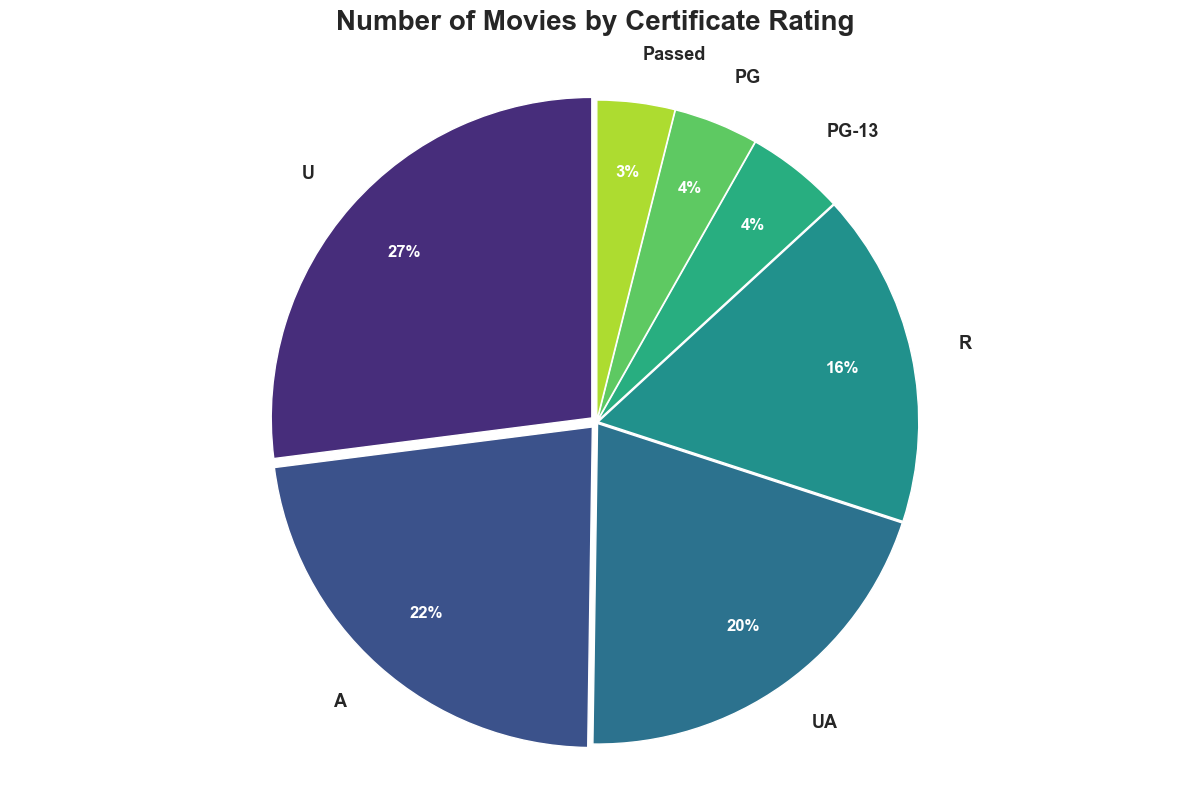

In [283]:
counts = df['Certificate'].value_counts().head(7)

fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette("viridis", n_colors=len(counts))

explode = [0.02 if i < 2 else 0.005 for i in range(len(counts))]

wedges, texts, autotexts = ax.pie(
    x = counts.values,
    labels = counts.index,
    autopct = '%i%%',        
    startangle = 90,             
    colors = colors,
    explode = explode,
    textprops = {'fontsize': 13, 'fontweight': 'bold'},
    pctdistance = 0.78, 
    labeldistance = 1.15
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax.set_title('Number of Movies by Certificate Rating', fontsize=20, fontweight='bold', pad=25)
ax.axis('equal')

plt.tight_layout()
plt.show()

<Axes: >

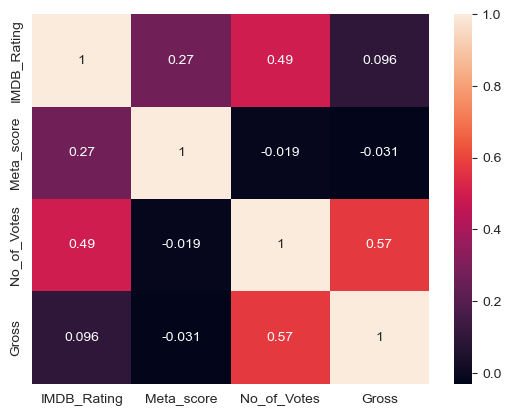

In [284]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

## Data Cleaning 

In [285]:
df.isnull().sum()

Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Meta_score       157
Director           0
Star1              0
No_of_Votes        0
Gross            169
dtype: int64

In [286]:
df.Certificate.fillna(df.Certificate.mode()[0], inplace = True)

In [287]:
df['Meta_score'].fillna(df['Meta_score'].median(), inplace = True)

In [288]:
df['Gross'].fillna(df['Gross'].median(), inplace = True)

In [289]:
df.isnull().sum()

Series_Title     0
Released_Year    0
Certificate      0
Runtime          0
Genre            0
IMDB_Rating      0
Meta_score       0
Director         0
Star1            0
No_of_Votes      0
Gross            0
dtype: int64

In [290]:
outlier = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']

for i in outlier:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[i] = df[i].clip(lower = lower_bound, upper = upper_bound)

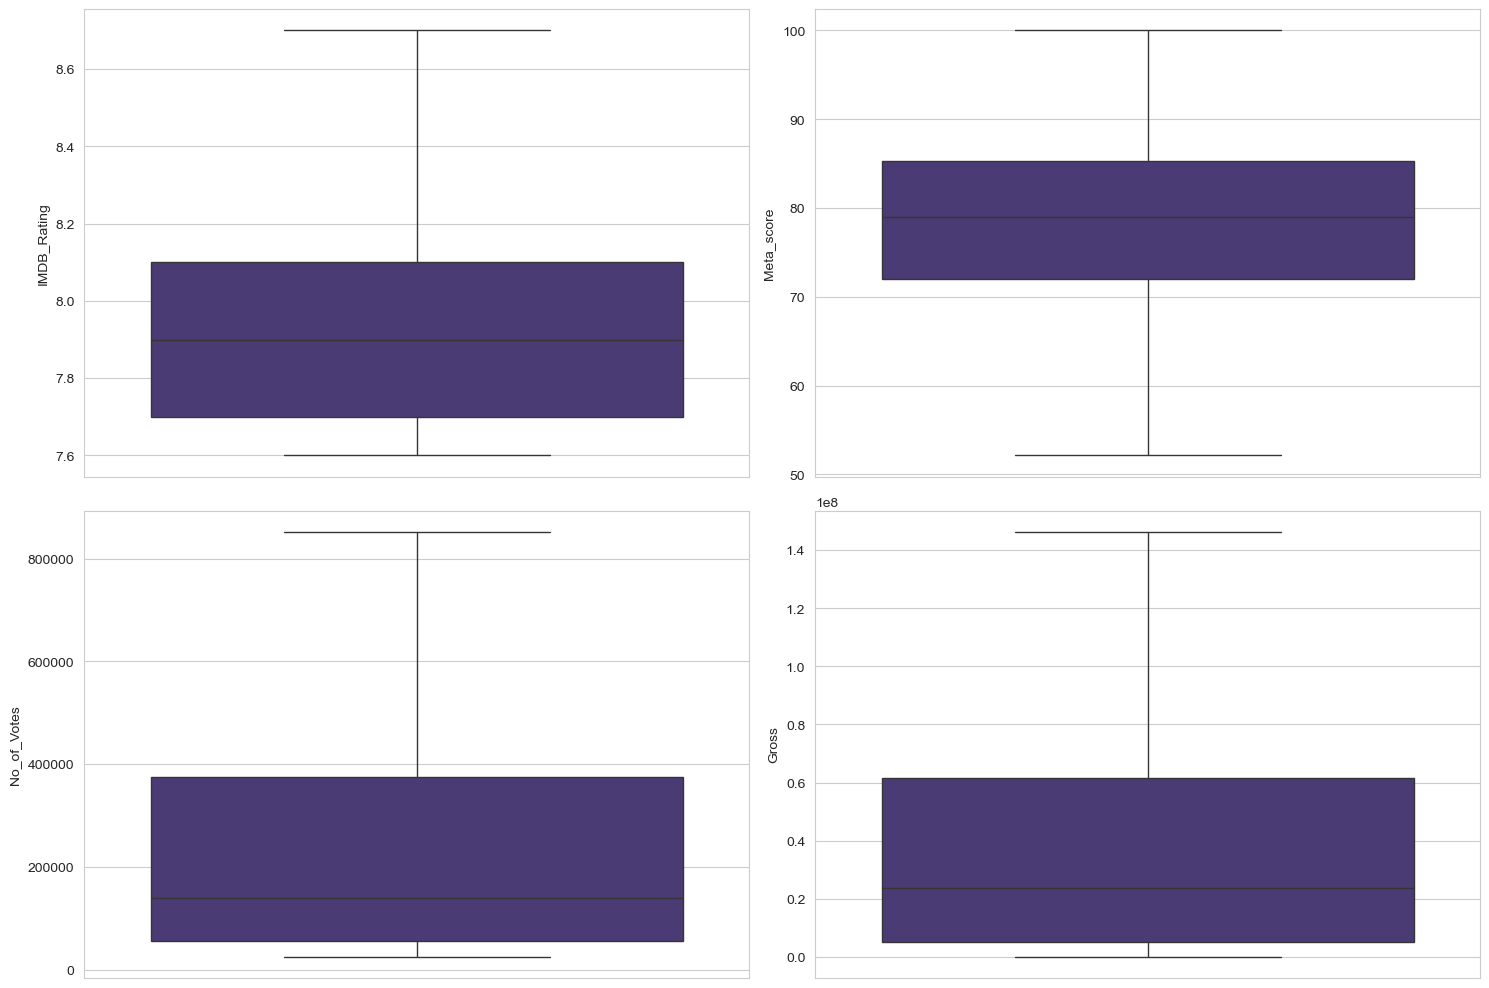

In [291]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

sns.set_style("whitegrid")

for i, col in enumerate(outlier):
    sns.boxplot(df[col], ax = axes[i])

for j in range(len(outlier), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [292]:
df.head(2)

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,Director,Star1,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142 min,Drama,8.7,80.0,Frank Darabont,Tim Robbins,852113.75,28341469.0
1,The Godfather,1972,A,175 min,"Crime, Drama",8.7,100.0,Francis Ford Coppola,Marlon Brando,852113.75,134966411.0


In [293]:
df.dtypes

Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Meta_score       float64
Director          object
Star1             object
No_of_Votes      float64
Gross            float64
dtype: object

In [294]:
df['Released_Year'].unique()

array(['1994', '1972', '2008', '1974', '1957', '2003', '1993', '2010',
       '1999', '2001', '1966', '2002', '1990', '1980', '1975', '2020',
       '2019', '2014', '1998', '1997', '1995', '1991', '1977', '1962',
       '1954', '1946', '2011', '2006', '2000', '1988', '1985', '1968',
       '1960', '1942', '1936', '1931', '2018', '2017', '2016', '2012',
       '2009', '2007', '1984', '1981', '1979', '1971', '1963', '1964',
       '1950', '1940', '2013', '2005', '2004', '1992', '1987', '1986',
       '1983', '1976', '1973', '1965', '1959', '1958', '1952', '1948',
       '1944', '1941', '1927', '1921', '2015', '1996', '1989', '1978',
       '1961', '1955', '1953', '1925', '1924', '1982', '1967', '1951',
       '1949', '1939', '1937', '1934', '1928', '1926', '1920', '1970',
       '1969', '1956', '1947', '1945', '1930', '1938', '1935', '1933',
       '1932', '1922', '1943', 'PG'], dtype=object)

In [295]:
df.loc[df['Released_Year'] == 'PG', 'Released_Year'] = '1995'

In [296]:
df[df['Released_Year'] == 'PG']

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,Director,Star1,No_of_Votes,Gross


In [297]:
df['Released_Year'] = df['Released_Year'].astype(int)

In [298]:
df.Released_Year.dtype

dtype('int64')

In [299]:
df.Certificate.unique()

array(['A', 'UA', 'U', 'PG-13', 'R', 'PG', 'G', 'Passed', 'TV-14', '16',
       'TV-MA', 'Unrated', 'GP', 'Approved', 'TV-PG', 'U/A'], dtype=object)

In [300]:
df['Runtime'] = df['Runtime'].str.replace(' min', '')

In [301]:
df['Runtime'] = df['Runtime'].astype(int)
df['Runtime'].dtype

dtype('int64')

In [302]:
df.head(2)

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,Director,Star1,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142,Drama,8.7,80.0,Frank Darabont,Tim Robbins,852113.75,28341469.0
1,The Godfather,1972,A,175,"Crime, Drama",8.7,100.0,Francis Ford Coppola,Marlon Brando,852113.75,134966411.0


In [303]:
df.dtypes

Series_Title      object
Released_Year      int64
Certificate       object
Runtime            int64
Genre             object
IMDB_Rating      float64
Meta_score       float64
Director          object
Star1             object
No_of_Votes      float64
Gross            float64
dtype: object

## Feature Enginering

In [304]:
import datetime

current_year = 2026
df['Movie_Age'] = current_year - df['Released_Year']

In [305]:
director_stats = df.groupby('Director')['Gross'].agg(['mean', 'count']).rename(
    columns = {'mean': 'Director_Avg_Gross', 'count': 'Director_Movie_Count'}
)

df = df.merge(director_stats, on = 'Director', how = 'left')

In [306]:
global_avg = df['IMDB_Rating'].mean()
min_votes = df['No_of_Votes'].quantile(0.75)  

df['Weighted_Rating'] = ((df['IMDB_Rating'] * df['No_of_Votes']) + (global_avg * min_votes)) / (df['No_of_Votes'] + min_votes)

In [307]:
def categorize_gross(g):
    if g >= 1e9:
        return 'Blockbuster'
    elif g >= 5e8:
        return 'Hit'
    elif g >= 1e8:
        return 'Average'
    else:
        return 'Flop'

df['Gross_Category'] = df['Gross'].apply(categorize_gross)

In [308]:
df.head(2)

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,Director,Star1,No_of_Votes,Gross,Movie_Age,Director_Avg_Gross,Director_Movie_Count,Weighted_Rating,Gross_Category
0,The Shawshank Redemption,1994,A,142,Drama,8.7,80.0,Frank Darabont,Tim Robbins,852113.75,28341469.0,32,82571421.5,2,8.47,Flop
1,The Godfather,1972,A,175,"Crime, Drama",8.7,100.0,Francis Ford Coppola,Marlon Brando,852113.75,134966411.0,54,69364796.8,5,8.47,Average


In [309]:
final_df = df.drop(columns = ['Series_Title', 'Genre', 'Star1', 'Director'], axis = 1)

In [310]:
cert_mapping = {
    'U': 1, 'G': 1,
    'TV-PG': 2, 'GP': 2, 'UA': 2, 'U/A': 2, 'Passed': 2, 'Approved': 2,
    'PG': 3,
    'PG-13': 4, 'TV-14': 4,
    'R': 5, '16': 5,
    'TV-MA': 6,
    'A': 7,
    'Unrated': 0
}

final_df['Certificate_Encoded'] = final_df['Certificate'].map(cert_mapping)

In [311]:
final_df.drop(columns = ['Certificate'], axis = 1, inplace = True)

In [312]:
final_df = pd.get_dummies(final_df, drop_first = True, dtype = int)

In [313]:
final_df

,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross,Movie_Age,Director_Avg_Gross,Director_Movie_Count,Weighted_Rating,Certificate_Encoded,Gross_Category_Flop
0,1994,142,8.7,80.0,852113.75,2.834147e+07,32,8.257142e+07,2,8.470000,7,1
1,1972,175,8.7,100.0,852113.75,1.349664e+08,54,6.936480e+07,5,8.470000,7,0
2,2008,152,8.7,84.0,852113.75,1.463303e+08,18,1.195771e+08,8,8.470000,2,0
3,1974,202,8.7,90.0,852113.75,5.730000e+07,52,6.936480e+07,5,8.470000,7,1
4,1957,96,8.7,96.0,689845.00,4.360000e+06,69,3.233818e+07,5,8.434924,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,1961,115,7.6,76.0,166544.00,2.353089e+07,65,2.353089e+07,1,7.839566,7,1
996,1956,201,7.6,84.0,34075.00,2.353089e+07,70,2.353089e+07,1,7.917303,1,1
997,1953,118,7.6,85.0,43374.00,3.050000e+07,73,2.108906e+07,4,7.910236,2,1
998,1944,97,7.6,78.0,26471.00,2.353089e+07,82,1.691170e+07,14,7.923326,1,1


<Axes: >

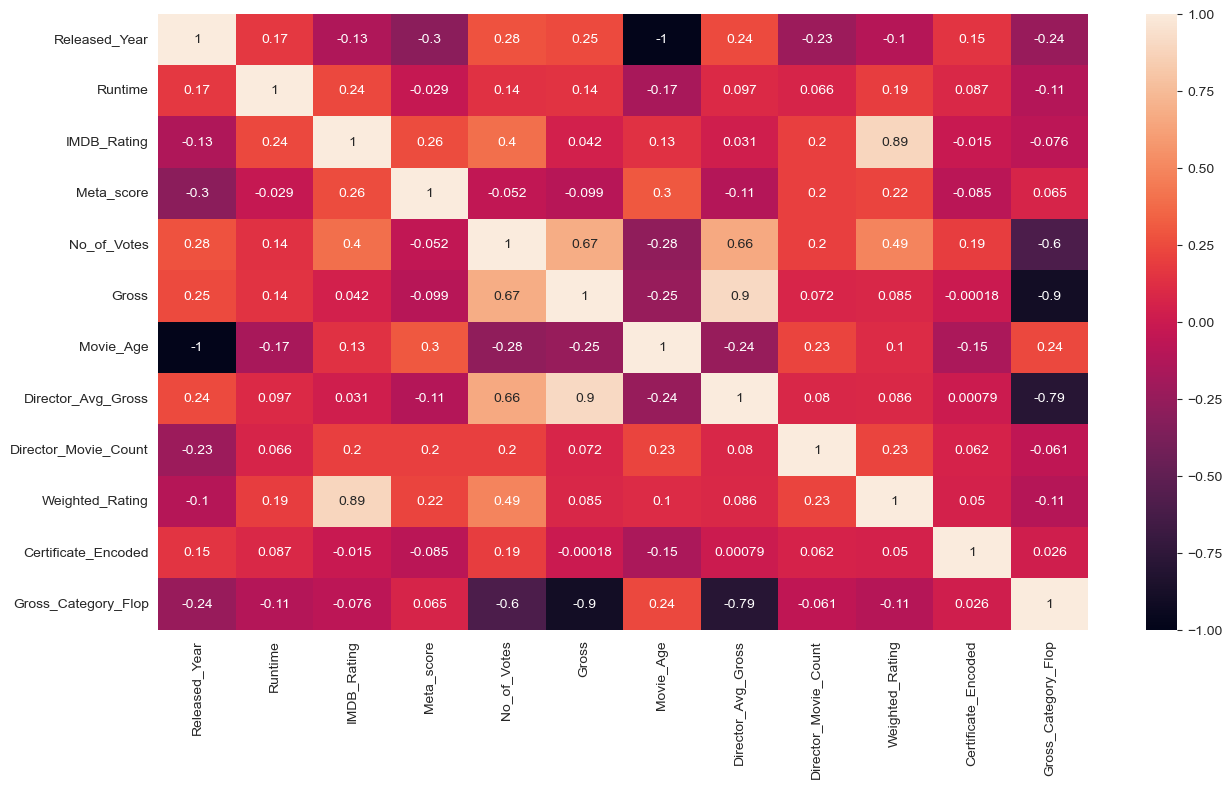

In [314]:
plt.figure(figsize = (15,  8))
sns.heatmap(final_df.corr(numeric_only = True), annot = True)

In [315]:
gross_df = final_df[['Released_Year', 'Runtime', 'No_of_Votes', 'Director_Avg_Gross', 'Weighted_Rating', 'IMDB_Rating', 'Director_Movie_Count', 'Meta_score', 'Gross']]

In [316]:
gross_df.head(3)

,Released_Year,Runtime,No_of_Votes,Director_Avg_Gross,Weighted_Rating,IMDB_Rating,Director_Movie_Count,Meta_score,Gross
0,1994,142,852113.75,8.257142e+07,8.47,8.7,2,80.0,2.834147e+07
1,1972,175,852113.75,6.936480e+07,8.47,8.7,5,100.0,1.349664e+08
2,2008,152,852113.75,1.195771e+08,8.47,8.7,8,84.0,1.463303e+08


## Train Test Split

In [317]:
from sklearn.model_selection import train_test_split

X = gross_df.drop(['Gross'], axis = 1)
y = gross_df['Gross']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

## Standard Scaling

In [318]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)    

## Model Training

In [319]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train) 

y_pred = lr.predict(X_test_scaled)

## Model Evaluation

In [320]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📈 Model Performance (on Gross Scale):")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"R-squared (R²) Score : {r2:.4f}")

📈 Model Performance (on Gross Scale):
Mean Squared Error (MSE) : 410187433670495.4375
Root Mean Squared Error (RMSE) : 20253084.5471
Mean Absolute Error (MAE) : 13521827.4421
R-squared (R²) Score : 0.8325


In [321]:
# Training data par prediction karo
y_train_pred = lr.predict(X_train_scaled)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

print(f"Training R²: {train_r2:.4f}")
print(f"Testing R² : {test_r2:.4f}")
print(f"Difference : {train_r2 - test_r2:.4f}")

Training R²: 0.8280
Testing R² : 0.8325
Difference : -0.0045


Residuals Summary:
Mean: 1641032.88
Std Dev: 20186491.64
Min: -79658035.57
Max: 74061549.57


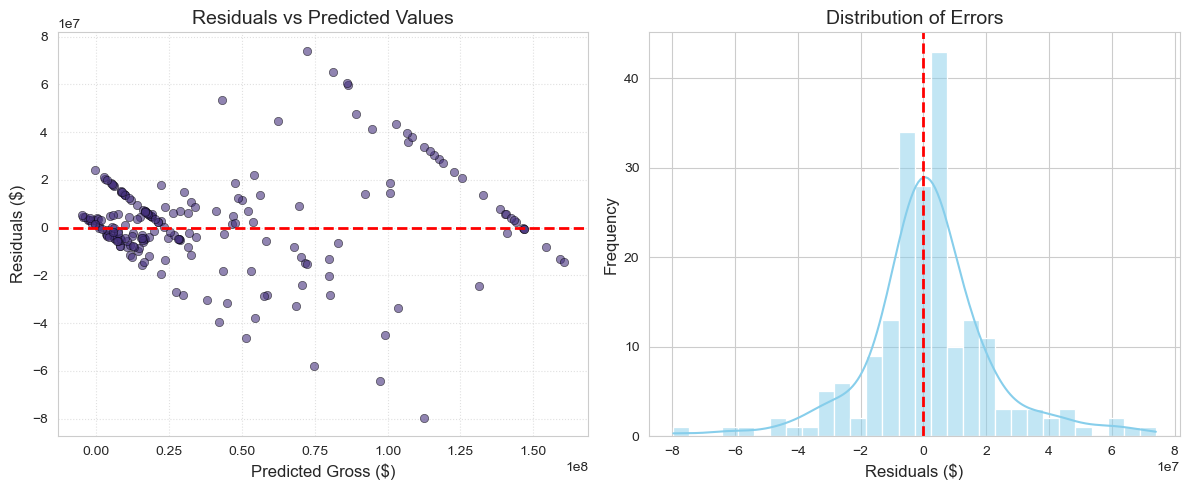

In [322]:
residuals = y_test - y_pred 

print(f"Residuals Summary:")
print(f"Mean: {np.mean(residuals):.2f}")
print(f"Std Dev: {np.std(residuals):.2f}")
print(f"Min: {np.min(residuals):.2f}")
print(f"Max: {np.max(residuals):.2f}")

plt.figure(figsize=(12, 5))

# Plot 1: Residuals vs Predicted (Scatter)
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Gross ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('Residuals vs Predicted Values', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Distribution of Residuals (Histogram)
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=30, color='skyblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Errors', fontsize=14)

plt.tight_layout()
plt.show()